# 01 - Exploratory Data Analysis

This notebook explores the Store Item Demand Forecasting dataset and identifies trend, seasonality and useful forecasting characteristics.

Dataset source: Kaggle Store Item Demand Forecasting Challenge.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

train = pd.read_csv("../data/train.csv", parse_dates=["date"])
train.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [3]:
print("Shape:", train.shape)
print("\nMissing values:")
print(train.isna().sum())
print("\nData types:")
print(train.dtypes)
print("\nStores:", train["store"].nunique())
print("Items:", train["item"].nunique())
print("Date range:", train["date"].min(), "to", train["date"].max())

Shape: (913000, 4)

Missing values:
date     0
store    0
item     0
sales    0
dtype: int64

Data types:
date     datetime64[ns]
store             int64
item              int64
sales             int64
dtype: object

Stores: 10
Items: 50
Date range: 2013-01-01 00:00:00 to 2017-12-31 00:00:00


In [4]:
train.describe(include="all")

,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 11:59:59.999999744,5.500000,25.500000,52.250287
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000
std,NaN,2.872283,14.430878,28.801144


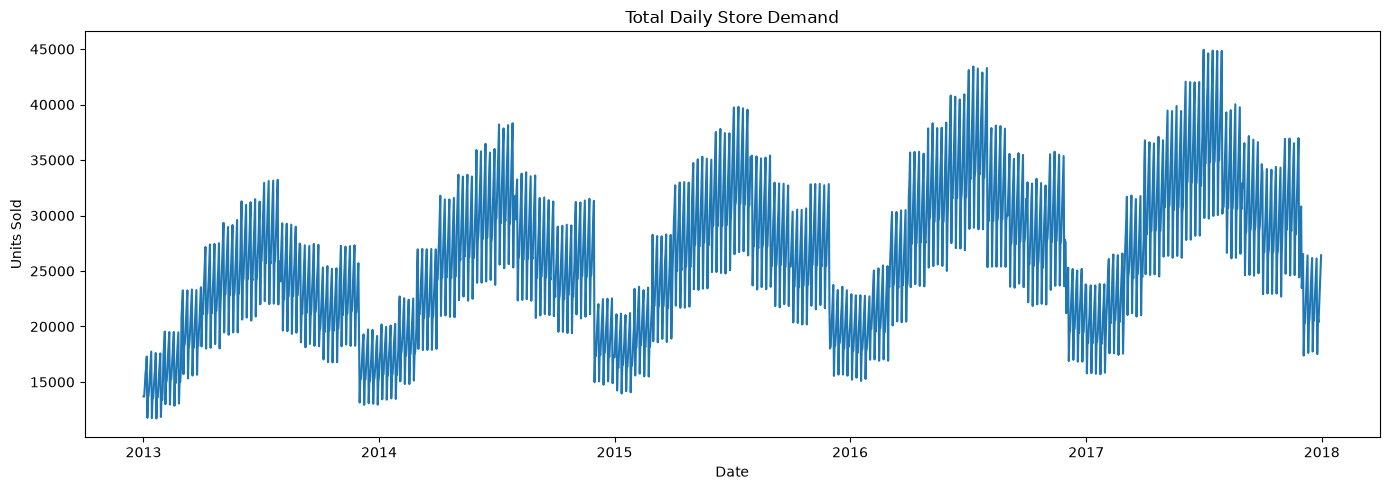

In [5]:
daily_total = train.groupby("date", as_index=False)["sales"].sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_total["date"], daily_total["sales"])
plt.title("Total Daily Store Demand")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

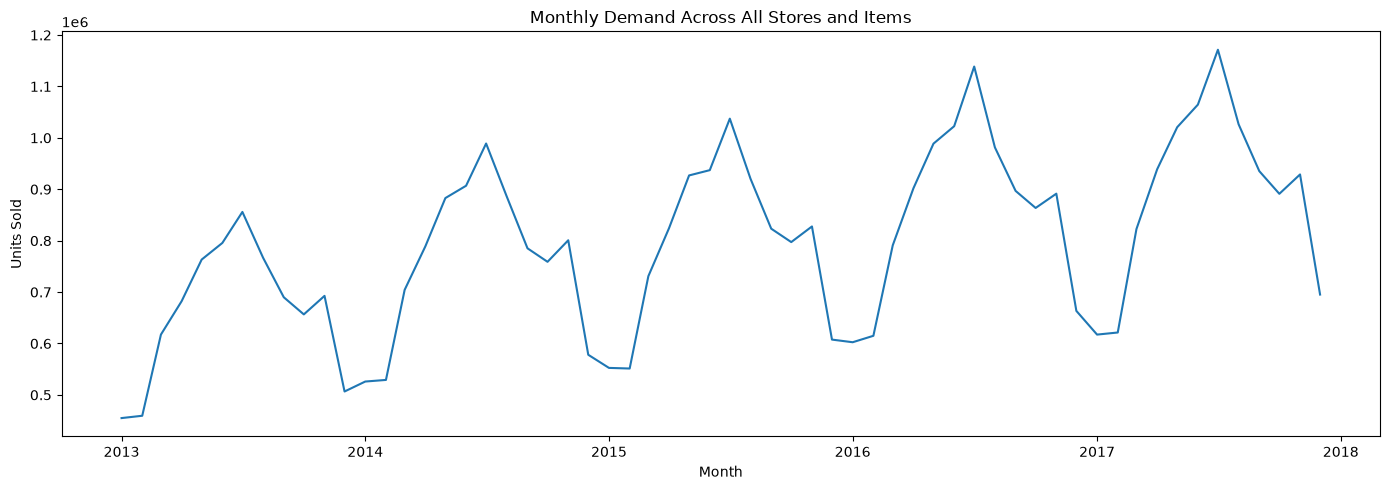

In [6]:
monthly = (
    train.assign(month=train["date"].dt.to_period("M"))
    .groupby("month", as_index=False)["sales"]
    .sum()
)
monthly["month"] = monthly["month"].dt.to_timestamp()

plt.figure(figsize=(14, 5))
plt.plot(monthly["month"], monthly["sales"])
plt.title("Monthly Demand Across All Stores and Items")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

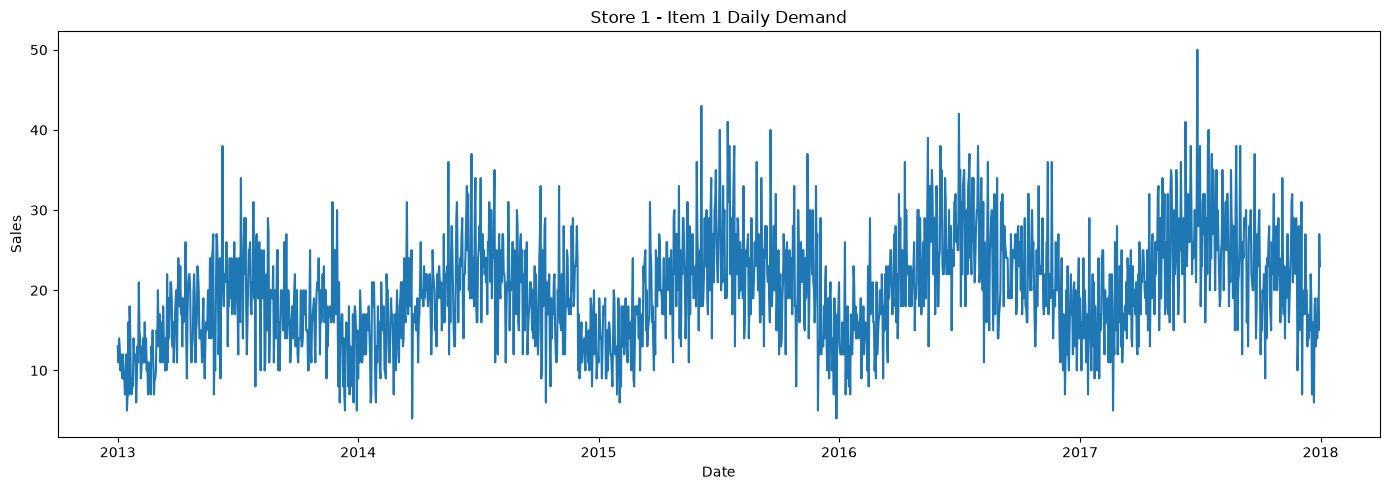

In [7]:
selected = train[(train["store"] == 1) & (train["item"] == 1)].copy()
selected = selected.sort_values("date")

plt.figure(figsize=(14, 5))
plt.plot(selected["date"], selected["sales"])
plt.title("Store 1 - Item 1 Daily Demand")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

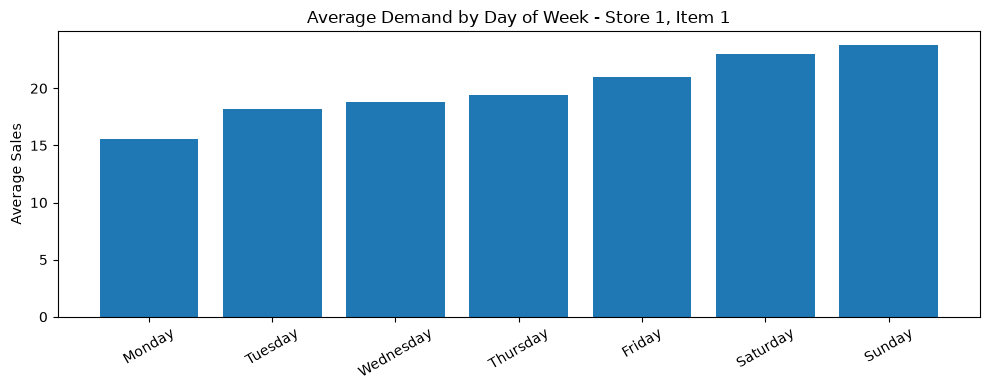

In [8]:
selected["day_of_week"] = selected["date"].dt.day_name()
weekday_avg = selected.groupby("day_of_week")["sales"].mean()

weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]
weekday_avg = weekday_avg.reindex(weekday_order)

plt.figure(figsize=(10, 4))
plt.bar(weekday_avg.index, weekday_avg.values)
plt.xticks(rotation=30)
plt.title("Average Demand by Day of Week - Store 1, Item 1")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

## EDA conclusions

The dataset contains repeated store-item time series rather than one single series. For a clear interview project, the next notebooks focus on one selected store-item combination.

The key forecasting observations to discuss are:

- demand changes over time,
- weekly patterns can appear in daily sales,
- the observations are ordered in time,
- and validation must respect chronology.